# EDA horario de la volatilidad futura

In [1]:
from pathlib import Path
import runpy
import pandas as pd
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/14_temporal_target.py').is_file())
RECALCULAR = False
if RECALCULAR:
    runpy.run_path(str(ROOT/'src/14_temporal_target.py'), run_name='__main__')
runpy.run_path(str(ROOT/'src/14_render_target_temporal.py'))['render'](False)
display(pd.read_csv(ROOT/'outputs/tables/temporal_target_stationarity.csv'))
display(pd.read_csv(ROOT/'outputs/tables/temporal_target_coverage.csv'))


Temporal horario del objetivo integrado.


,symbol,n,adf_stat,adf_p,adf_lags,kpss_stat,kpss_p,kpss_lags,kpss_warning
0,BNBUSDT,19901,-9.301000,1.112586e-15,48,1.125599,0.010000,85,The test statistic is outside of the range of ...
1,BTCUSDT,19901,-10.482177,1.205759e-18,48,1.891163,0.010000,85,The test statistic is outside of the range of ...
2,ETHUSDT,19901,-9.273062,1.310959e-15,48,6.587982,0.010000,85,The test statistic is outside of the range of ...
3,SOLUSDT,19901,-9.007441,6.256123e-15,48,0.462593,0.050175,85,NaN
4,XRPUSDT,19901,-9.530415,2.900952e-16,48,2.059769,0.010000,85,The test statistic is outside of the range of ...


,symbol,total_valid,segment_n,segment_start,segment_end
0,BNBUSDT,42539,19901,2023-03-24 14:00:00+00:00,2025-06-30 18:00:00+00:00
1,BTCUSDT,42539,19901,2023-03-24 14:00:00+00:00,2025-06-30 18:00:00+00:00
2,ETHUSDT,42539,19901,2023-03-24 14:00:00+00:00,2025-06-30 18:00:00+00:00
3,SOLUSDT,42564,19901,2023-03-24 14:00:00+00:00,2025-06-30 18:00:00+00:00
4,XRPUSDT,42564,19901,2023-03-24 14:00:00+00:00,2025-06-30 18:00:00+00:00


### 2.6.10 Análisis horario del objetivo definitivo

El análisis anterior del precio se complementa con el objetivo realmente pronosticado: desviación estándar centrada de los 24 retornos logarítmicos horarios futuros, multiplicada por 100, con divisor 24 y sin anualización. Cada etiqueta exige 25 cierres consecutivos y convencionales. Se conserva la rejilla horaria, se invalidan las ventanas afectadas por huecos y se excluyen las últimas 24 anclas de DEVELOPMENT. TEST no se abre.

**Este análisis es retrospectivo.** El objetivo futuro, sus momentos móviles y su descomposición STL no son entradas disponibles al emitir la predicción; no se incorporan al pipeline. Se incluyen para diagnosticar la serie. Los patrones de calendario se agrupan por el instante nominal de emisión (apertura del ancla + 1 hora, UTC).

La serie completa, los momentos móviles y los ciclos utilizan todas las etiquetas válidas de DEVELOPMENT. ACF/PACF, ADF, KPSS y STL requieren una secuencia regular: se usa exclusivamente el tramo válido consecutivo más largo, elegido por cobertura, sin interpolar. Los resultados de ese tramo no representan necesariamente los periodos excluidos.

| Activo | Etiquetas válidas | n del tramo | Inicio ancla UTC | Fin ancla UTC |
| --- | --- | --- | --- | --- |
| BNBUSDT | 42539 | 19901 | 2023-03-24 14:00:00+00:00 | 2025-06-30 18:00:00+00:00 |
| BTCUSDT | 42539 | 19901 | 2023-03-24 14:00:00+00:00 | 2025-06-30 18:00:00+00:00 |
| ETHUSDT | 42539 | 19901 | 2023-03-24 14:00:00+00:00 | 2025-06-30 18:00:00+00:00 |
| SOLUSDT | 42564 | 19901 | 2023-03-24 14:00:00+00:00 | 2025-06-30 18:00:00+00:00 |
| XRPUSDT | 42564 | 19901 | 2023-03-24 14:00:00+00:00 | 2025-06-30 18:00:00+00:00 |

#### Dependencia horaria y efecto del solapamiento

Se calculan ACF y PACF hasta 168 horas; PACF utiliza Levinson–Durbin sin ajuste de sesgo (`ldbiased`). Los primeros rezagos se resumen a continuación. No se presentan bandas iid como evidencia inferencial. Los objetivos consecutivos comparten 23 retornos: una ACF elevada no demuestra capacidad predictiva ni independencia de las filas. Como contraste descriptivo se calcula la ACF de los retornos absolutos y al cuadrado, que no son objetivos de 24 horas superpuestos.

| Activo | Rezago h | ACF y | PACF y | ACF \|r\| | ACF r² |
| --- | --- | --- | --- | --- | --- |
| BNBUSDT | 1 | 0.9892 | 0.9892 | 0.2947 | 0.1668 |
| BNBUSDT | 24 | 0.5252 | 0.0362 | 0.1621 | 0.0792 |
| BNBUSDT | 168 | 0.3109 | 0.0029 | 0.1094 | 0.0410 |
| BTCUSDT | 1 | 0.9865 | 0.9865 | 0.2664 | 0.1883 |
| BTCUSDT | 24 | 0.4241 | 0.0091 | 0.1358 | 0.0567 |
| BTCUSDT | 168 | 0.3270 | -0.0153 | 0.1490 | 0.0691 |
| ETHUSDT | 1 | 0.9860 | 0.9860 | 0.2494 | 0.1192 |
| ETHUSDT | 24 | 0.4700 | 0.0069 | 0.1397 | 0.0351 |
| ETHUSDT | 168 | 0.3127 | -0.0015 | 0.1226 | 0.0458 |
| SOLUSDT | 1 | 0.9879 | 0.9879 | 0.2311 | 0.1719 |
| SOLUSDT | 24 | 0.5385 | 0.0065 | 0.1471 | 0.0682 |
| SOLUSDT | 168 | 0.2496 | 0.0077 | 0.0920 | 0.0379 |
| XRPUSDT | 1 | 0.9883 | 0.9883 | 0.3545 | 0.1650 |
| XRPUSDT | 24 | 0.5130 | 0.0114 | 0.1772 | 0.0398 |
| XRPUSDT | 168 | 0.2851 | -0.0006 | 0.1193 | 0.0135 |

La ACF del objetivo a una hora va de 0.9860 a 0.9892 entre activos; a 168 horas va de 0.2496 a 0.3270. La dependencia no se limita al primer rezago. Su interpretación requiere considerar tanto el solapamiento como la evolución del proceso.

La ACF de retornos transformados se calcula en su propio tramo consecutivo más largo, cuyos límites se guardan en el CSV; no se supone que coincida exactamente con el del objetivo. La relación con los rezagos de close continúa documentada en 2.6.5 y no se interpreta como causalidad.

#### Estacionariedad: hipótesis y límites

ADF se ejecuta con constante, máximo 48 rezagos horarios y selección AIC dentro de ese máximo; su hipótesis nula es raíz unitaria. KPSS se ejecuta con constante y rezagos automáticos; su hipótesis nula es estacionariedad en nivel. Se reportan ambas salidas; no rechazar una hipótesis no equivale a demostrarla. El horizonte solapado, la selección de tramo y los cambios de distribución limitan la extrapolación. Son diez contrastes exploratorios, no un criterio de selección de variables ni de hiperparámetros; no se declara significación conjunta.

| Activo | ADF estadístico | ADF p | Rezagos ADF | KPSS estadístico | KPSS p tabulado | Rezagos KPSS |
| --- | --- | --- | --- | --- | --- | --- |
| BNBUSDT | -9.3010 | 1.1126e-15 | 48 | 1.1256 | ≤0.01 | 85 |
| BTCUSDT | -10.4822 | 1.2058e-18 | 48 | 1.8912 | ≤0.01 | 85 |
| ETHUSDT | -9.2731 | 1.311e-15 | 48 | 6.5880 | ≤0.01 | 85 |
| SOLUSDT | -9.0074 | 6.2561e-15 | 48 | 0.4626 | 0.05018 | 85 |
| XRPUSDT | -9.5304 | 2.901e-16 | 48 | 2.0598 | ≤0.01 | 85 |

BNBUSDT: ADF rechaza raíz unitaria y KPSS rechaza estacionariedad en nivel, usando 0,05 solo como referencia descriptiva. BTCUSDT: ADF rechaza raíz unitaria y KPSS rechaza estacionariedad en nivel, usando 0,05 solo como referencia descriptiva. ETHUSDT: ADF rechaza raíz unitaria y KPSS rechaza estacionariedad en nivel, usando 0,05 solo como referencia descriptiva. SOLUSDT: ADF rechaza raíz unitaria y KPSS no rechaza estacionariedad en nivel, usando 0,05 solo como referencia descriptiva. XRPUSDT: ADF rechaza raíz unitaria y KPSS rechaza estacionariedad en nivel, usando 0,05 solo como referencia descriptiva.

Los p-valores KPSS pueden ser límites de la tabla (0,01 o 0,10), no valores exactos. Las advertencias originales se conservan en `temporal_target_stationarity.csv`. Rechazar ambas hipótesis puede indicar que ninguna simplificación describe bien el tramo; no se resuelve declarando la serie estacionaria por una sola prueba.

#### Calendario, momentos móviles y evolución trimestral

Los paneles incluyen la media y la varianza móviles sobre 168 horas consecutivas con `min_periods=168`; no se calculan a través de faltantes. Las agregaciones diaria, semanal y mensual son promedios de etiquetas horarias válidas, no volatilidades recalculadas a otra frecuencia; la cobertura puede variar. Los boxplots muestran hora, día de semana y mes de emisión, ocultando únicamente los puntos extremos para facilitar la lectura, sin eliminarlos de las estadísticas.

La STL usa periodo diario de 24 horas, ajuste robusto e interpolación de los suavizadores cada tres puntos (`seasonal_jump=trend_jump=low_pass_jump=3`). Es una descomposición retrospectiva del tramo, no un filtro causal ni una prueba de estacionalidad estable. Se muestran tendencia, componente estacional y residuo. La descomposición semanal del precio analizada previamente responde a otra serie y frecuencia.

| Activo | Mediana mínima–máxima por hora (%) | Día semanal de menor mediana | Día semanal de mayor mediana |
| --- | --- | --- | --- |
| BNBUSDT | 0.5530 a 0.5652 | sábado | lunes |
| BTCUSDT | 0.4822 a 0.4876 | sábado | miércoles |
| ETHUSDT | 0.6138 a 0.6241 | sábado | miércoles |
| SOLUSDT | 0.9551 a 0.9683 | sábado | miércoles |
| XRPUSDT | 0.6726 a 0.6808 | sábado | lunes |

El rango entre medianas por hora permite valorar la magnitud del ciclo horario; cada objetivo cubre un día completo, lo que suaviza diferencias intradiarias. Los días con menor y mayor mediana son resúmenes del periodo observado, no efectos causales ni una regla garantizada para el futuro.

| Activo | Mínima mediana trimestral (%) | Máxima mediana trimestral (%) | Rango de DE trimestral (pp) |
| --- | --- | --- | --- |
| BNBUSDT | 0.2548 | 1.3237 | 0.1862 a 0.9410 |
| BTCUSDT | 0.2334 | 0.8989 | 0.1741 a 0.4642 |
| ETHUSDT | 0.2426 | 1.1125 | 0.1799 a 0.6826 |
| SOLUSDT | 0.6031 | 2.1078 | 0.2929 a 1.0460 |
| XRPUSDT | 0.4335 | 1.6374 | 0.2572 a 1.2107 |

Los resúmenes trimestrales comparan distribuciones del objetivo y complementan la deriva de close. Los trimestres extremos son parciales. Variación de la distribución marginal no prueba un cambio de la relación condicional entre predictores y objetivo (concept drift). La sección 2.6.11 amplía este diagnóstico con fechas candidatas de cambio e incertidumbre condicional y una cronología documentada de eventos. No se atribuyen causalmente los movimientos a esos eventos.

Las diferencias por calendario mezclan años y regímenes: no demuestran efectos horarios permanentes. Los paneles por activo permiten revisar heterogeneidad sin mezclar niveles. Estas comprobaciones sustentan la validación cronológica, la evaluación por fold y la incertidumbre por bloques; no modifican retrospectivamente la configuración del modelo ni consultan TEST.











#### Reproducción

Ejecutar `python src/14_temporal_target.py` y `python src/14_render_target_temporal.py`. Las tablas `outputs/tables/temporal_target_*.csv` conservan cobertura, ciclos, trimestres, componentes y diagnósticos. Los metadatos fijan convenciones y huella de DEVELOPMENT. [Notebook temporal del objetivo](./14_temporal_target.ipynb).

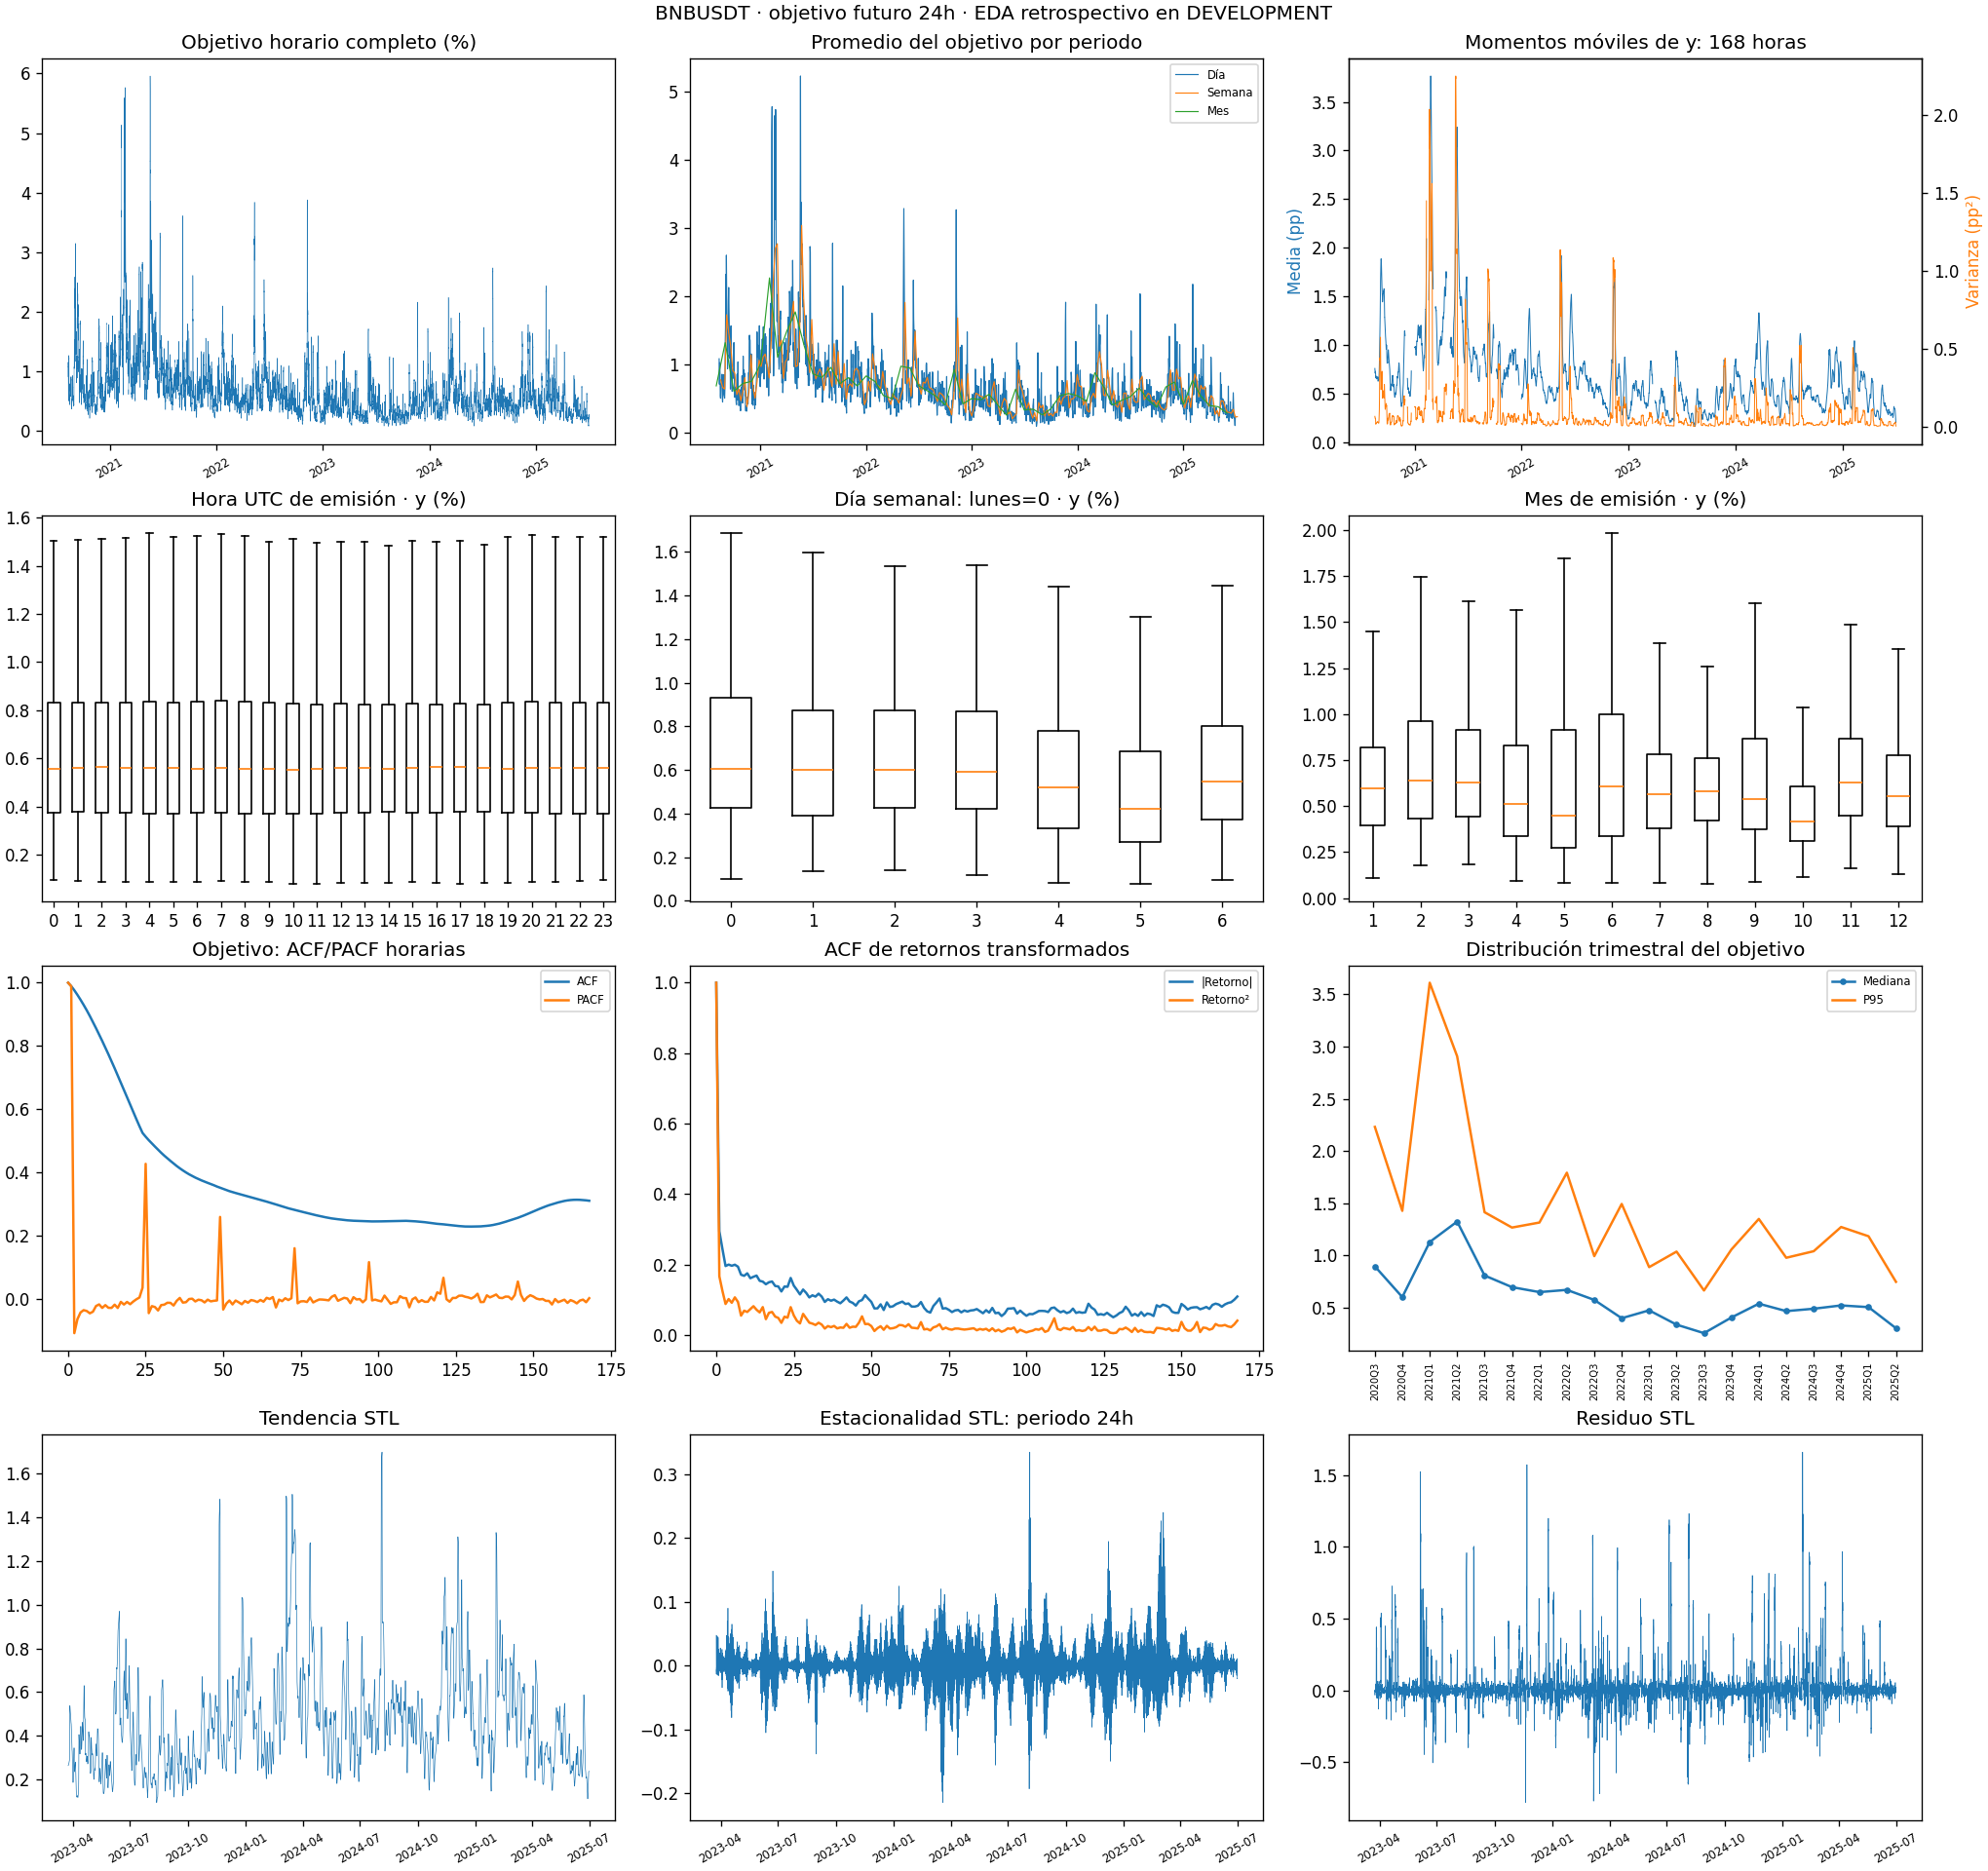

In [2]:
display(Image(filename=str(ROOT/'book/_static/figures/temporal_target_BNBUSDT.png')))

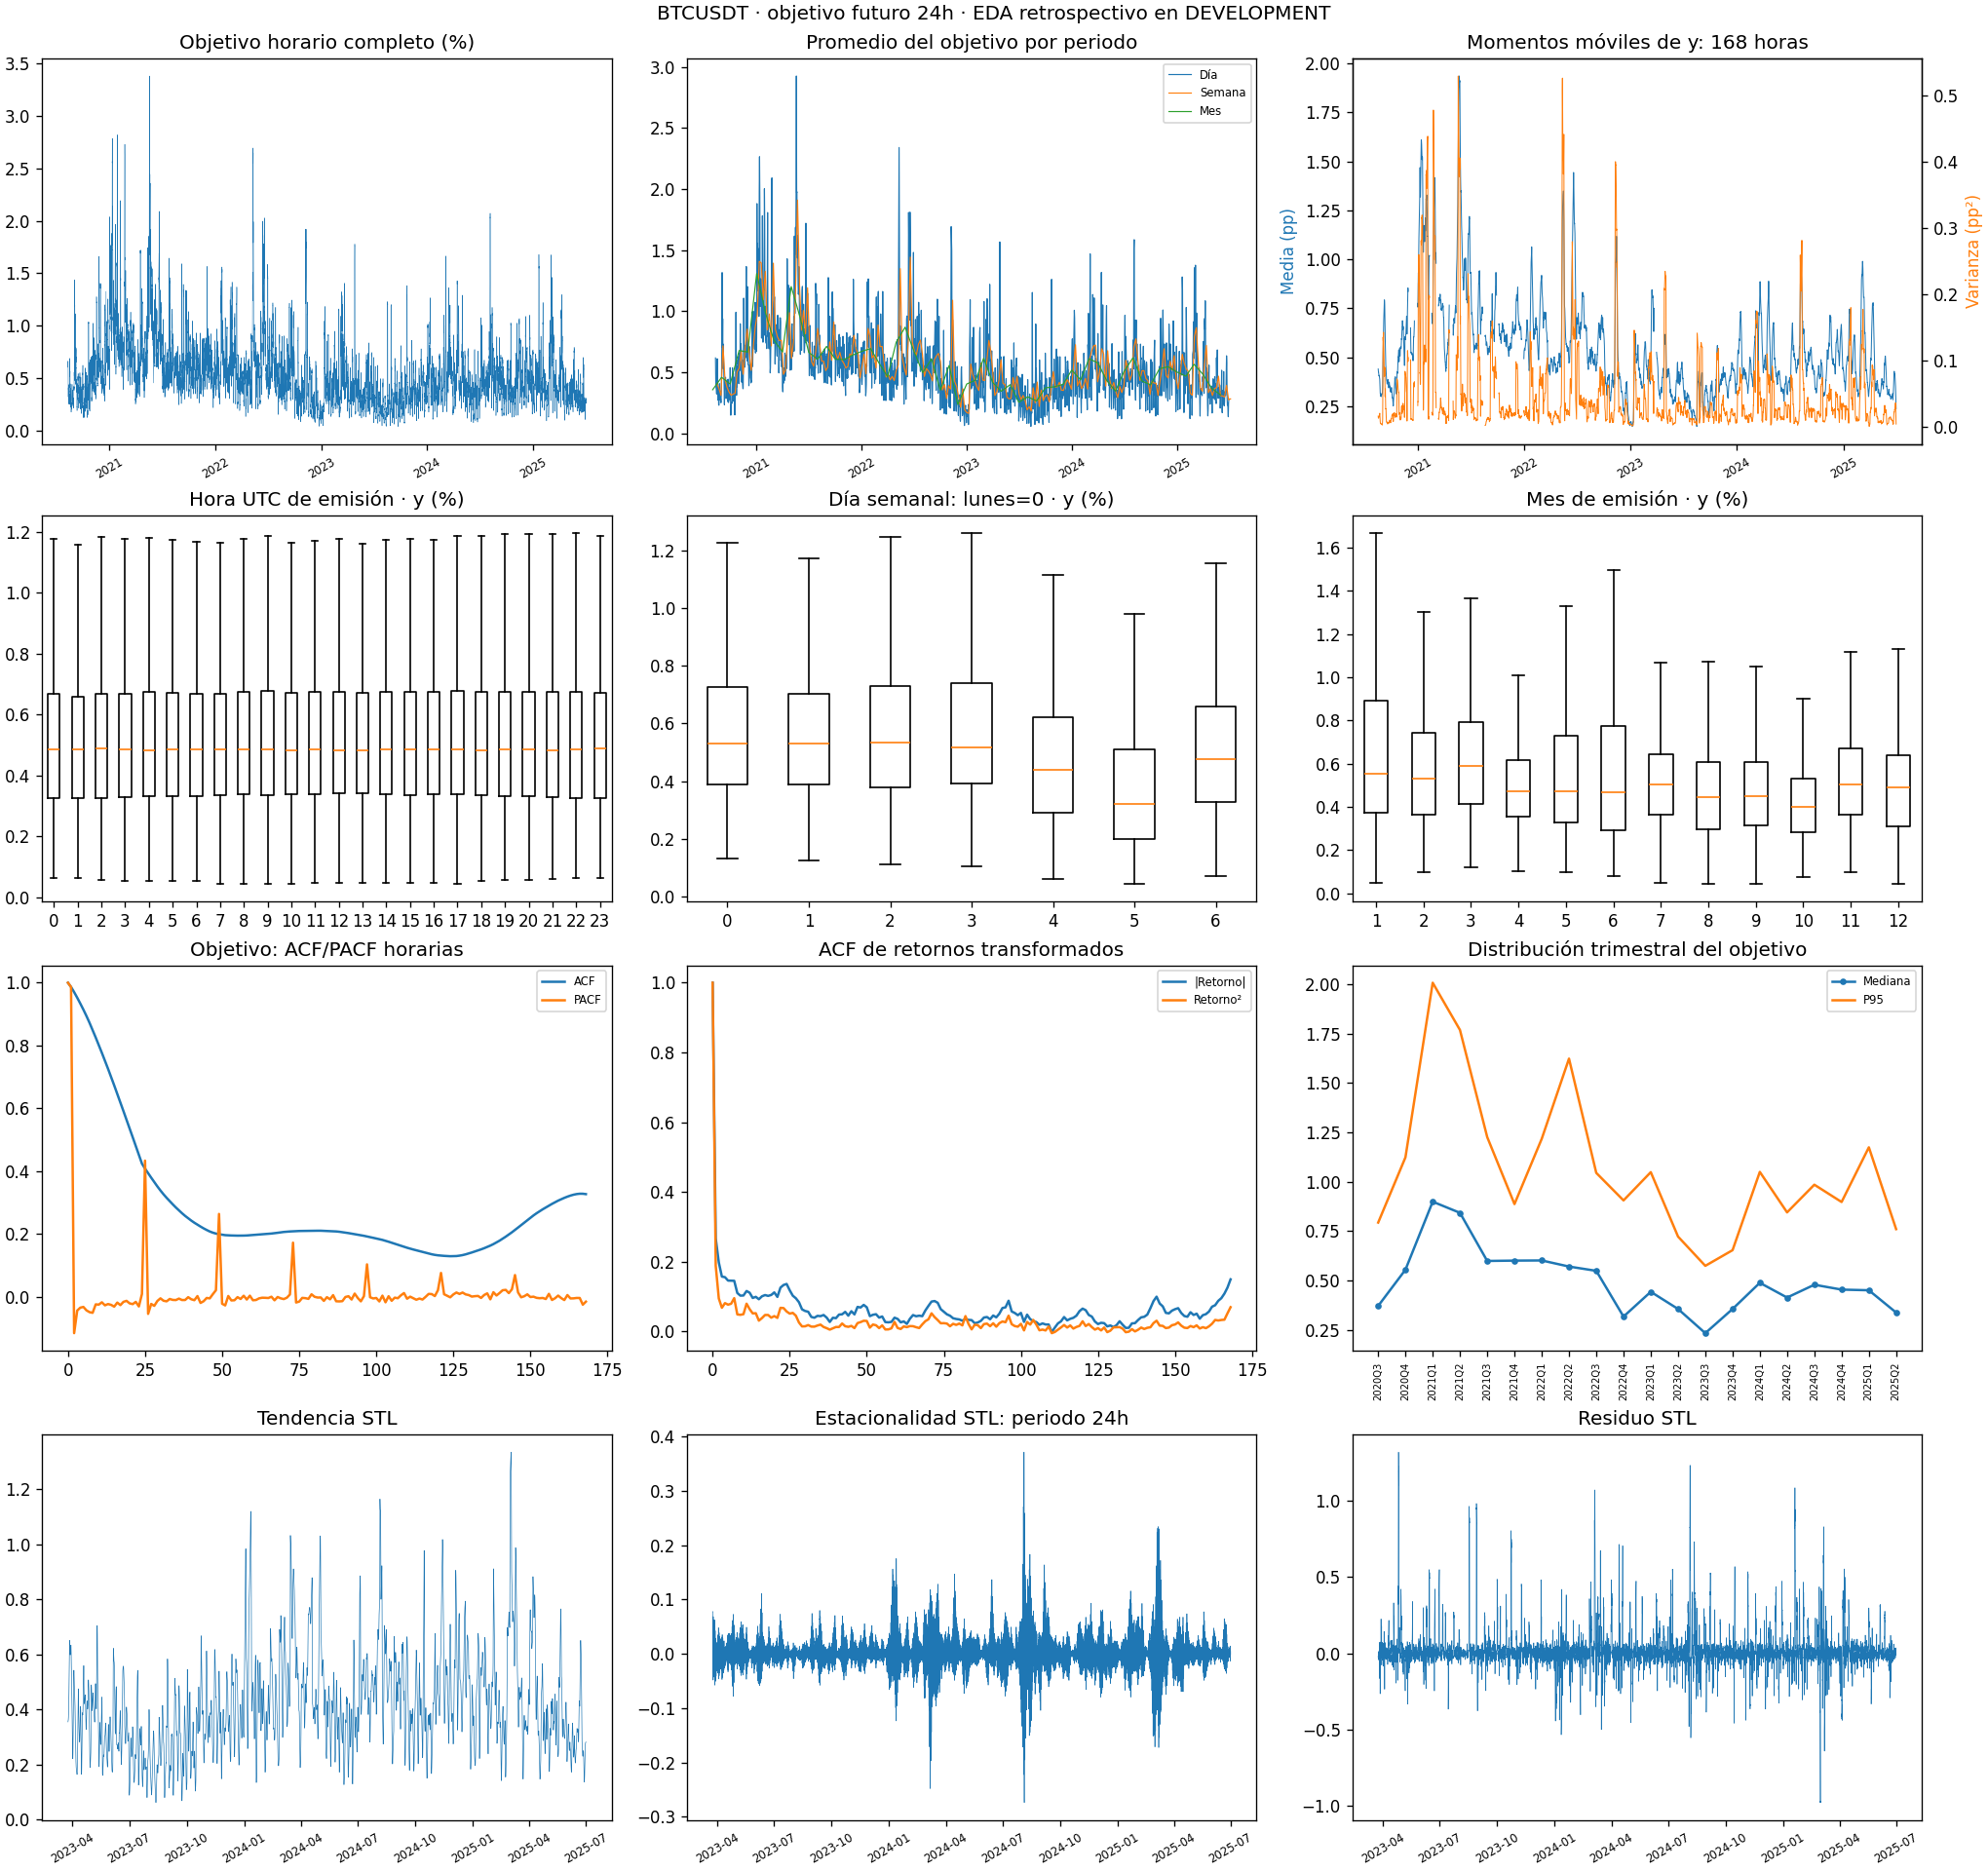

In [3]:
display(Image(filename=str(ROOT/'book/_static/figures/temporal_target_BTCUSDT.png')))

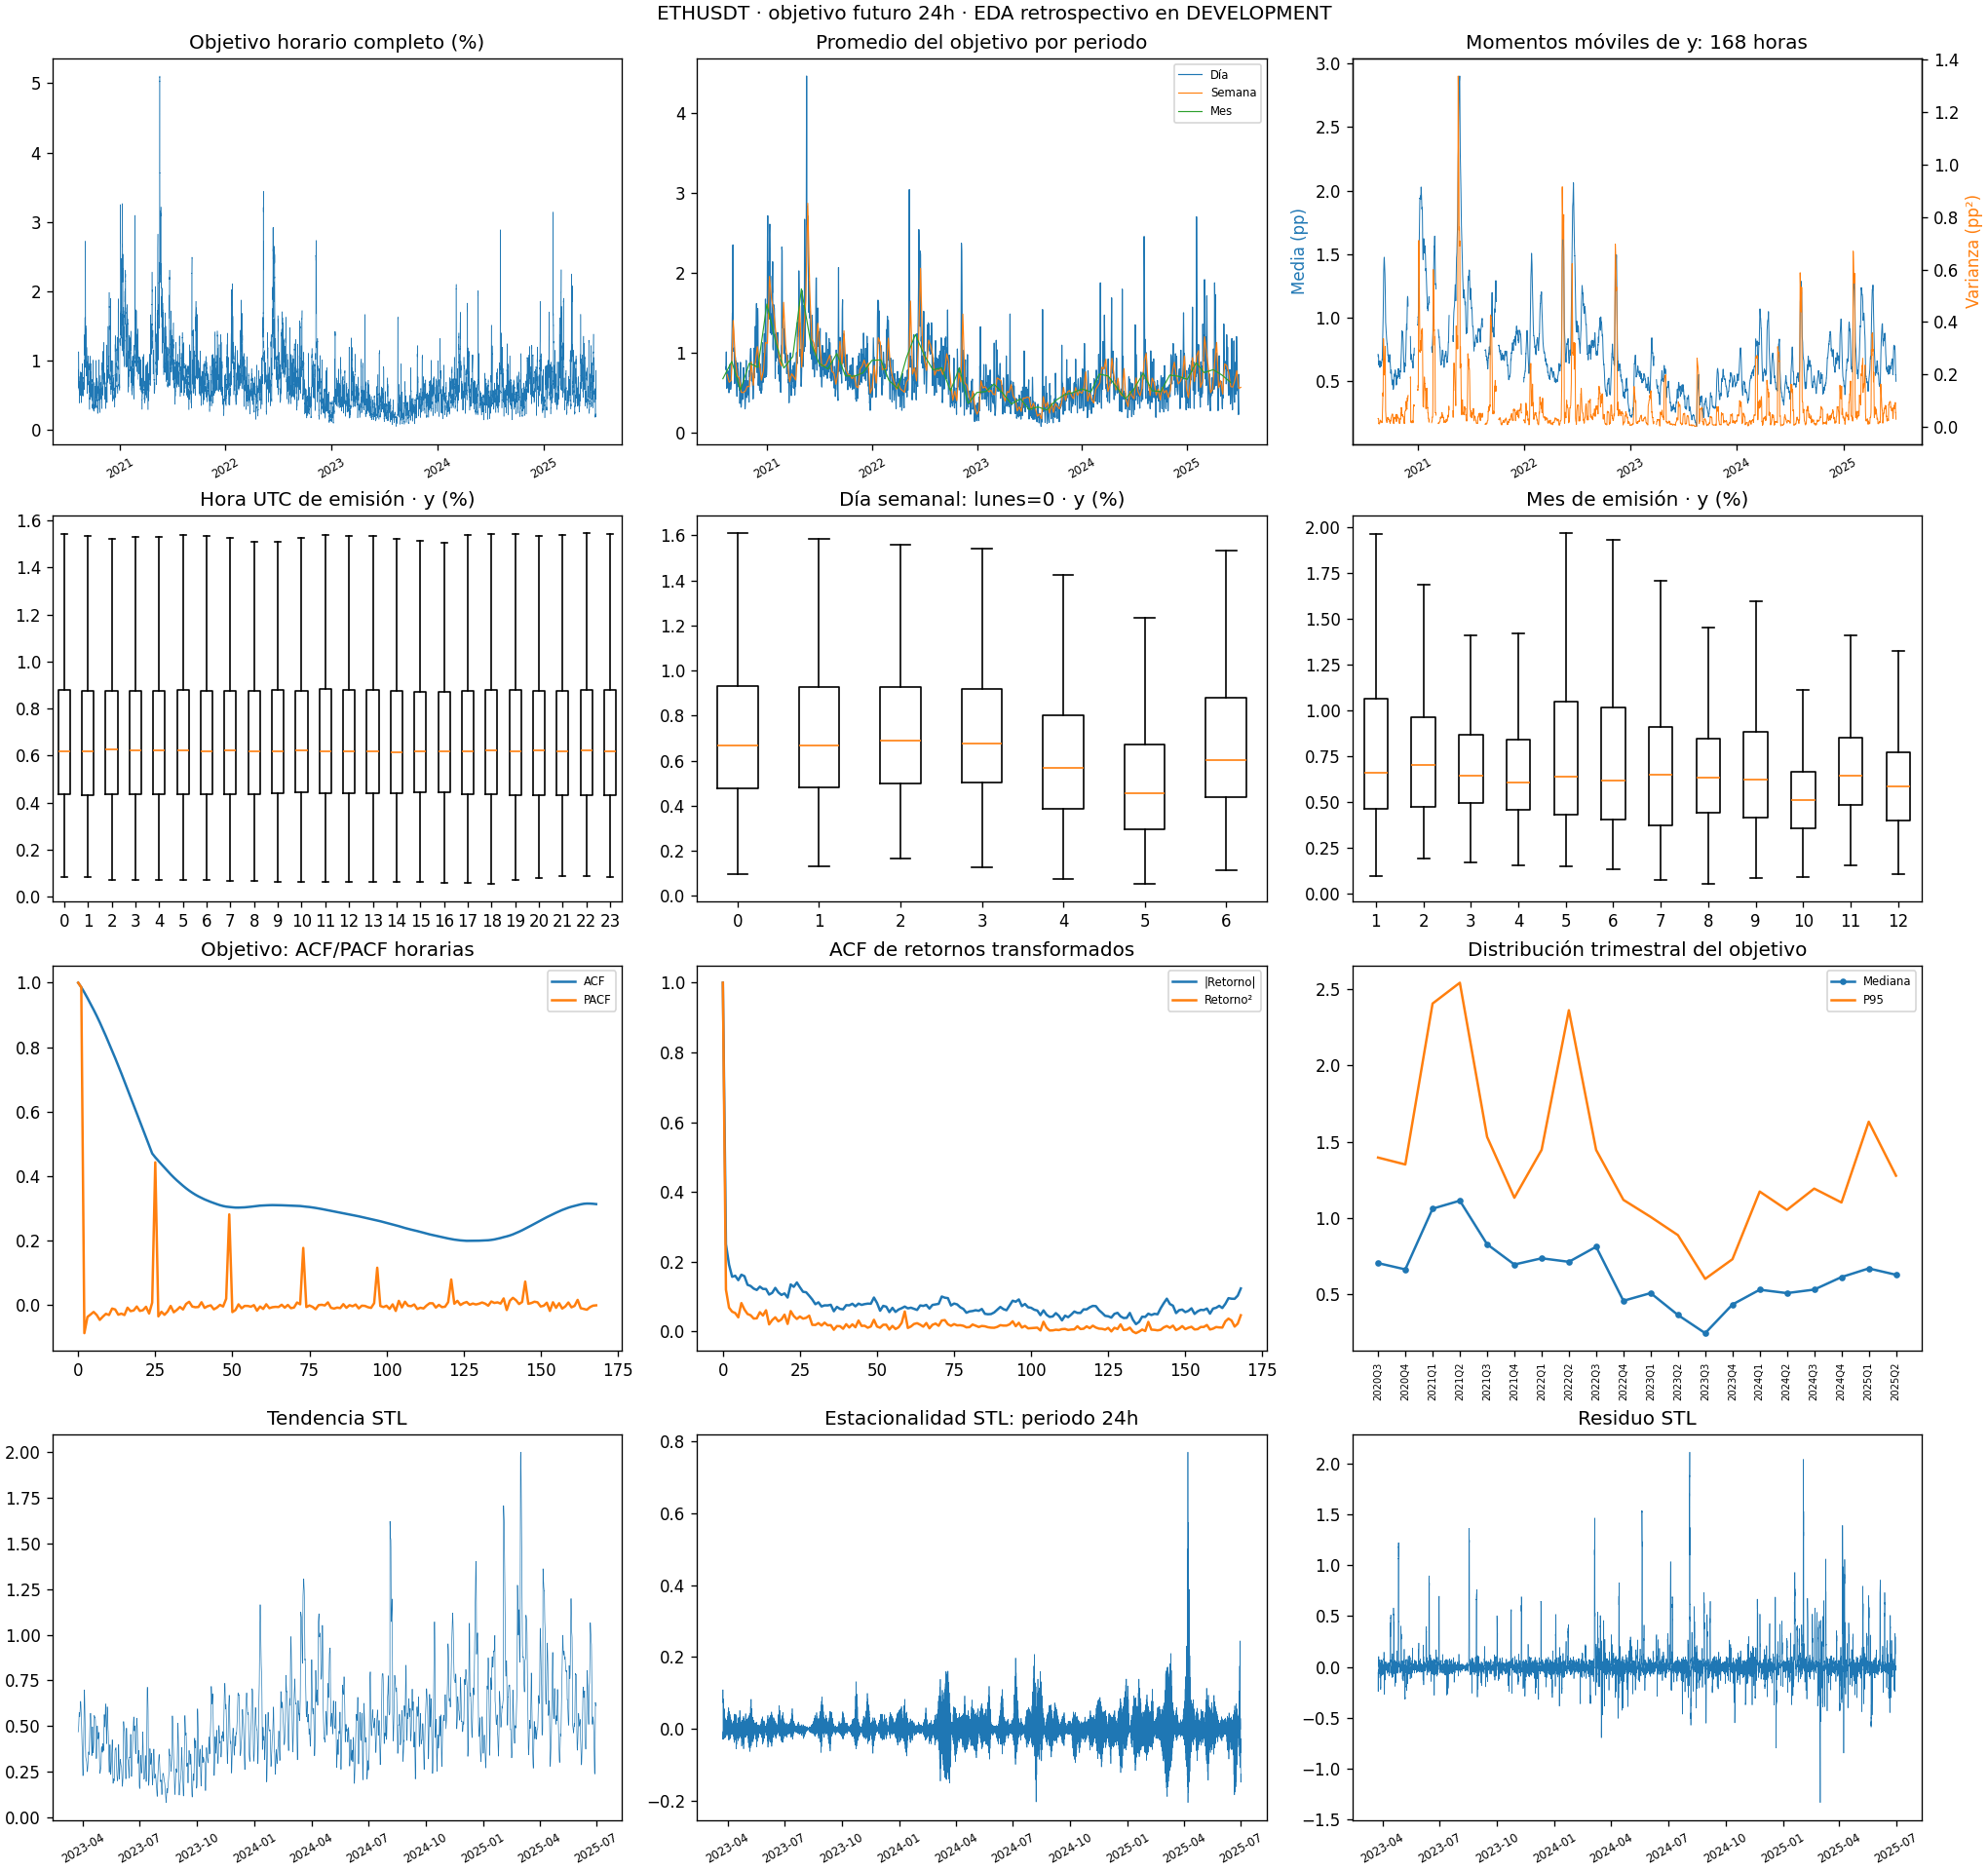

In [4]:
display(Image(filename=str(ROOT/'book/_static/figures/temporal_target_ETHUSDT.png')))

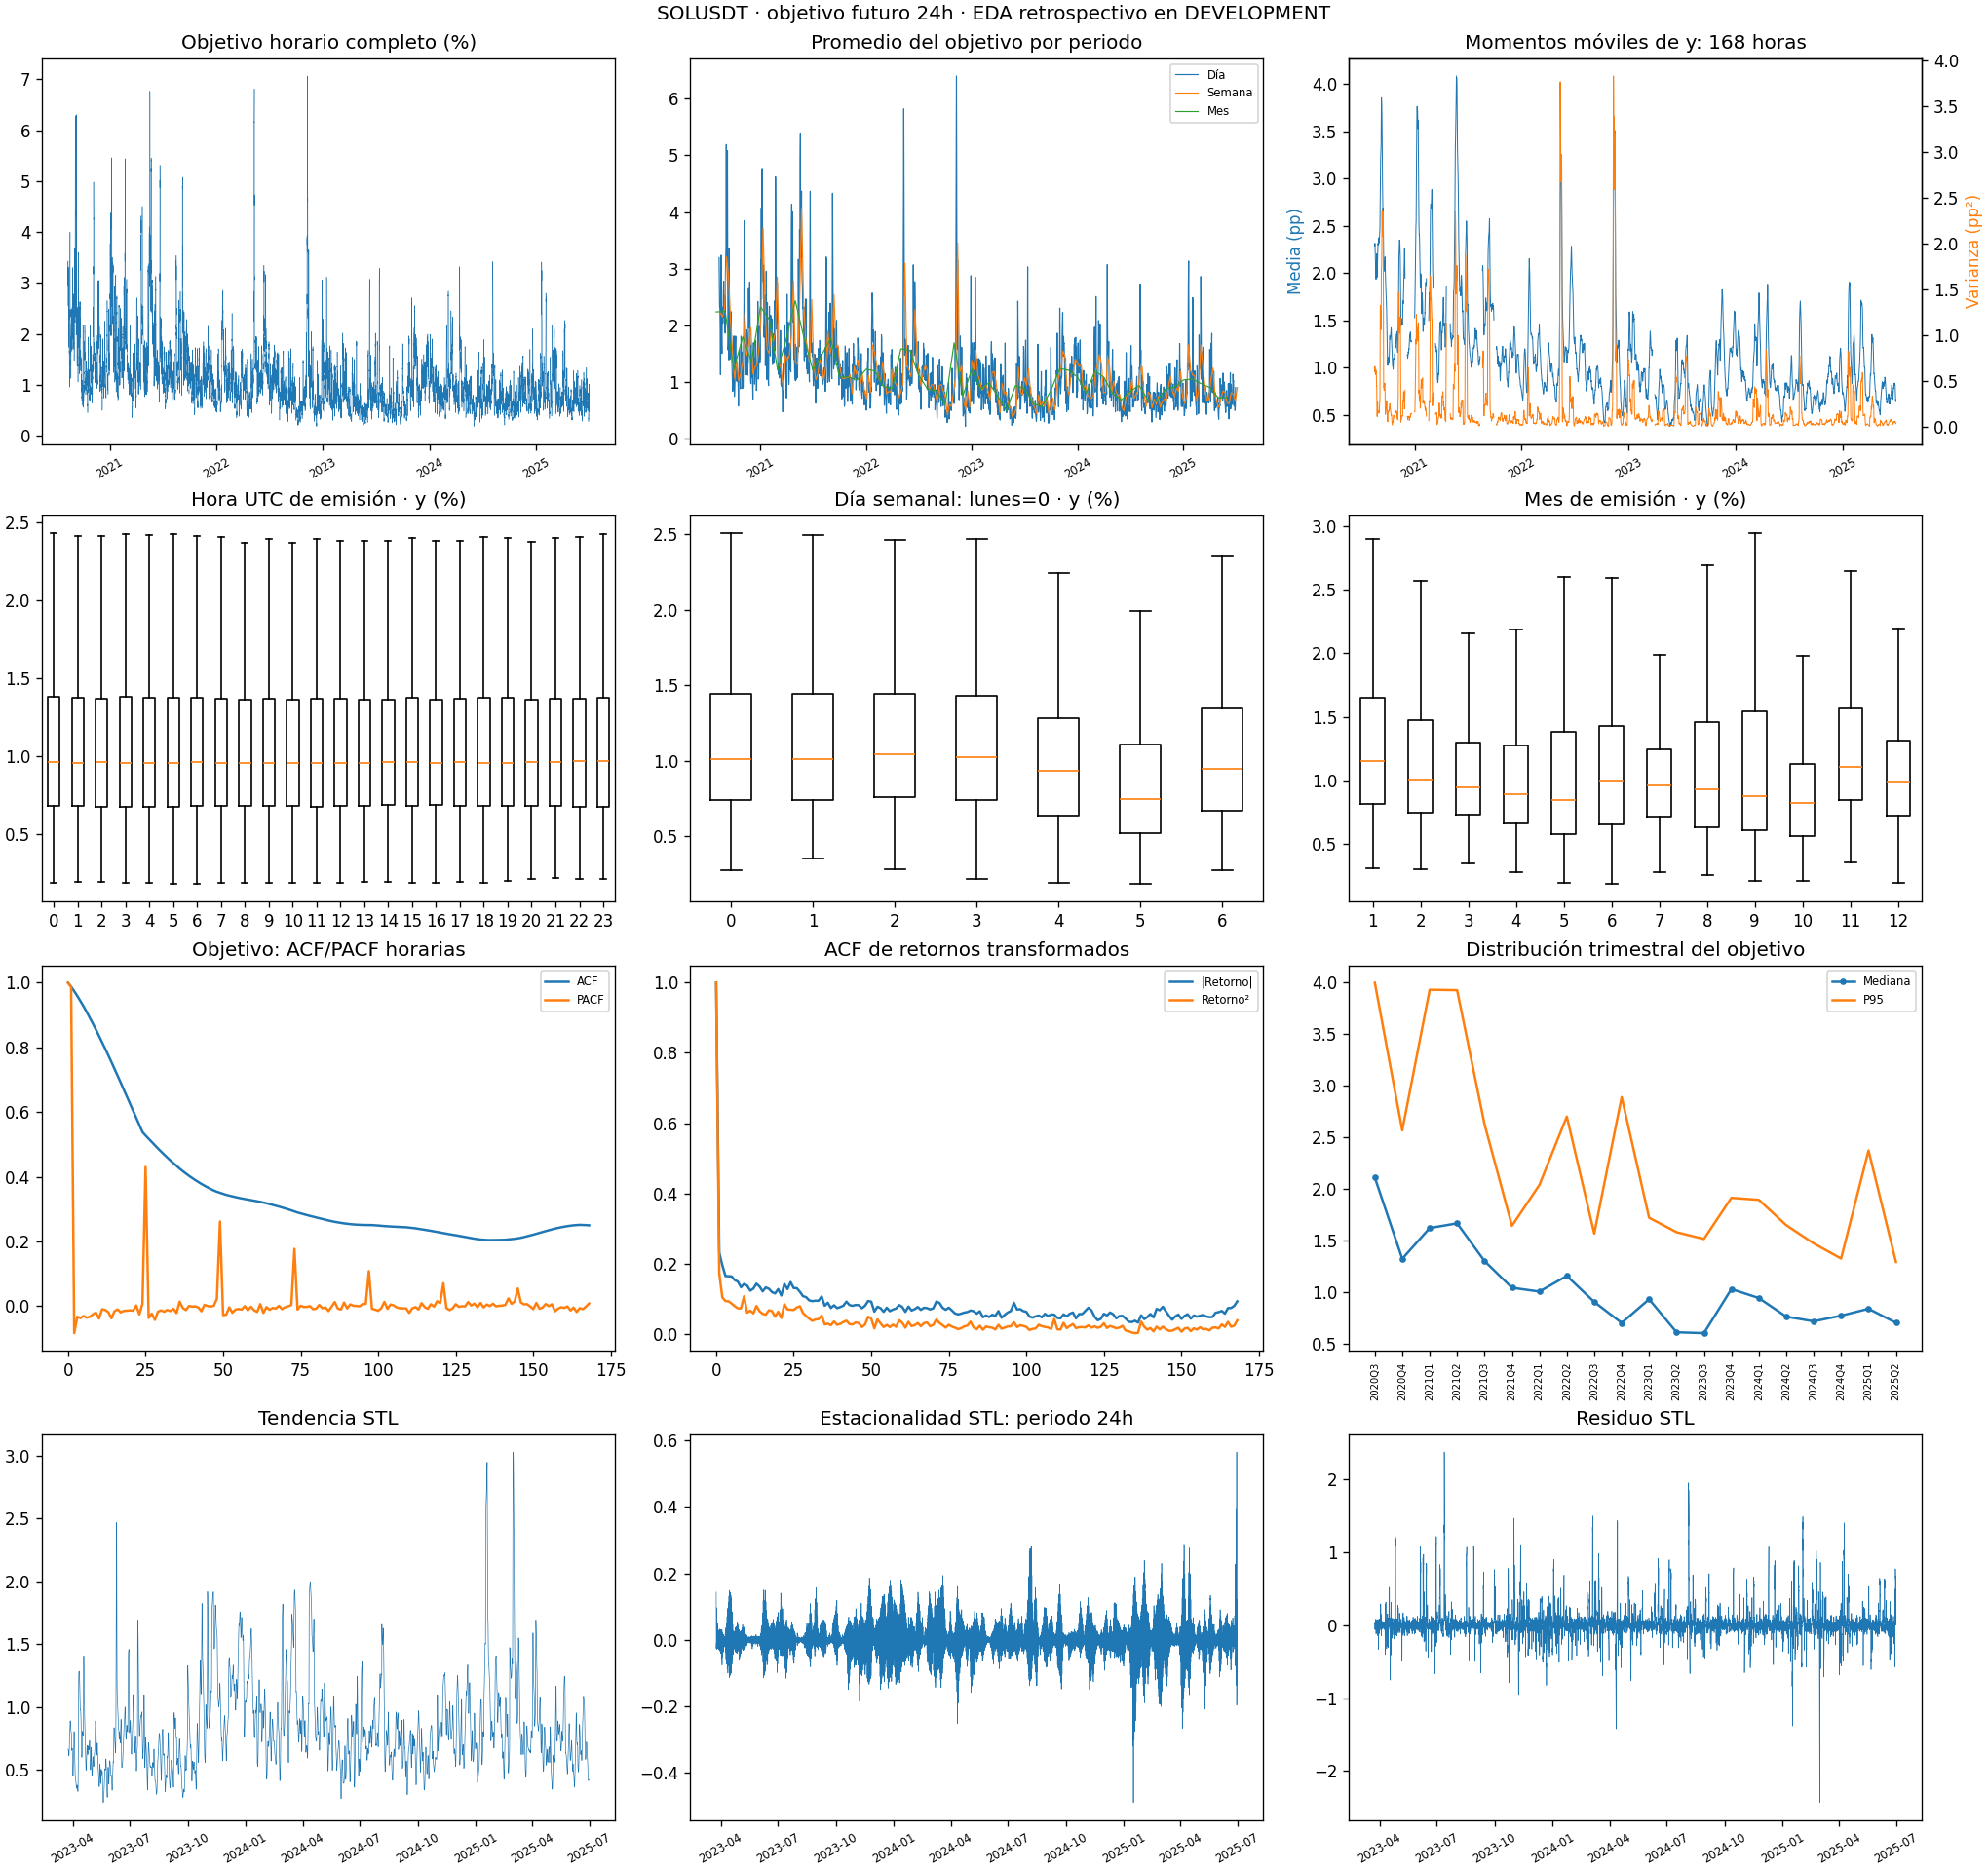

In [5]:
display(Image(filename=str(ROOT/'book/_static/figures/temporal_target_SOLUSDT.png')))

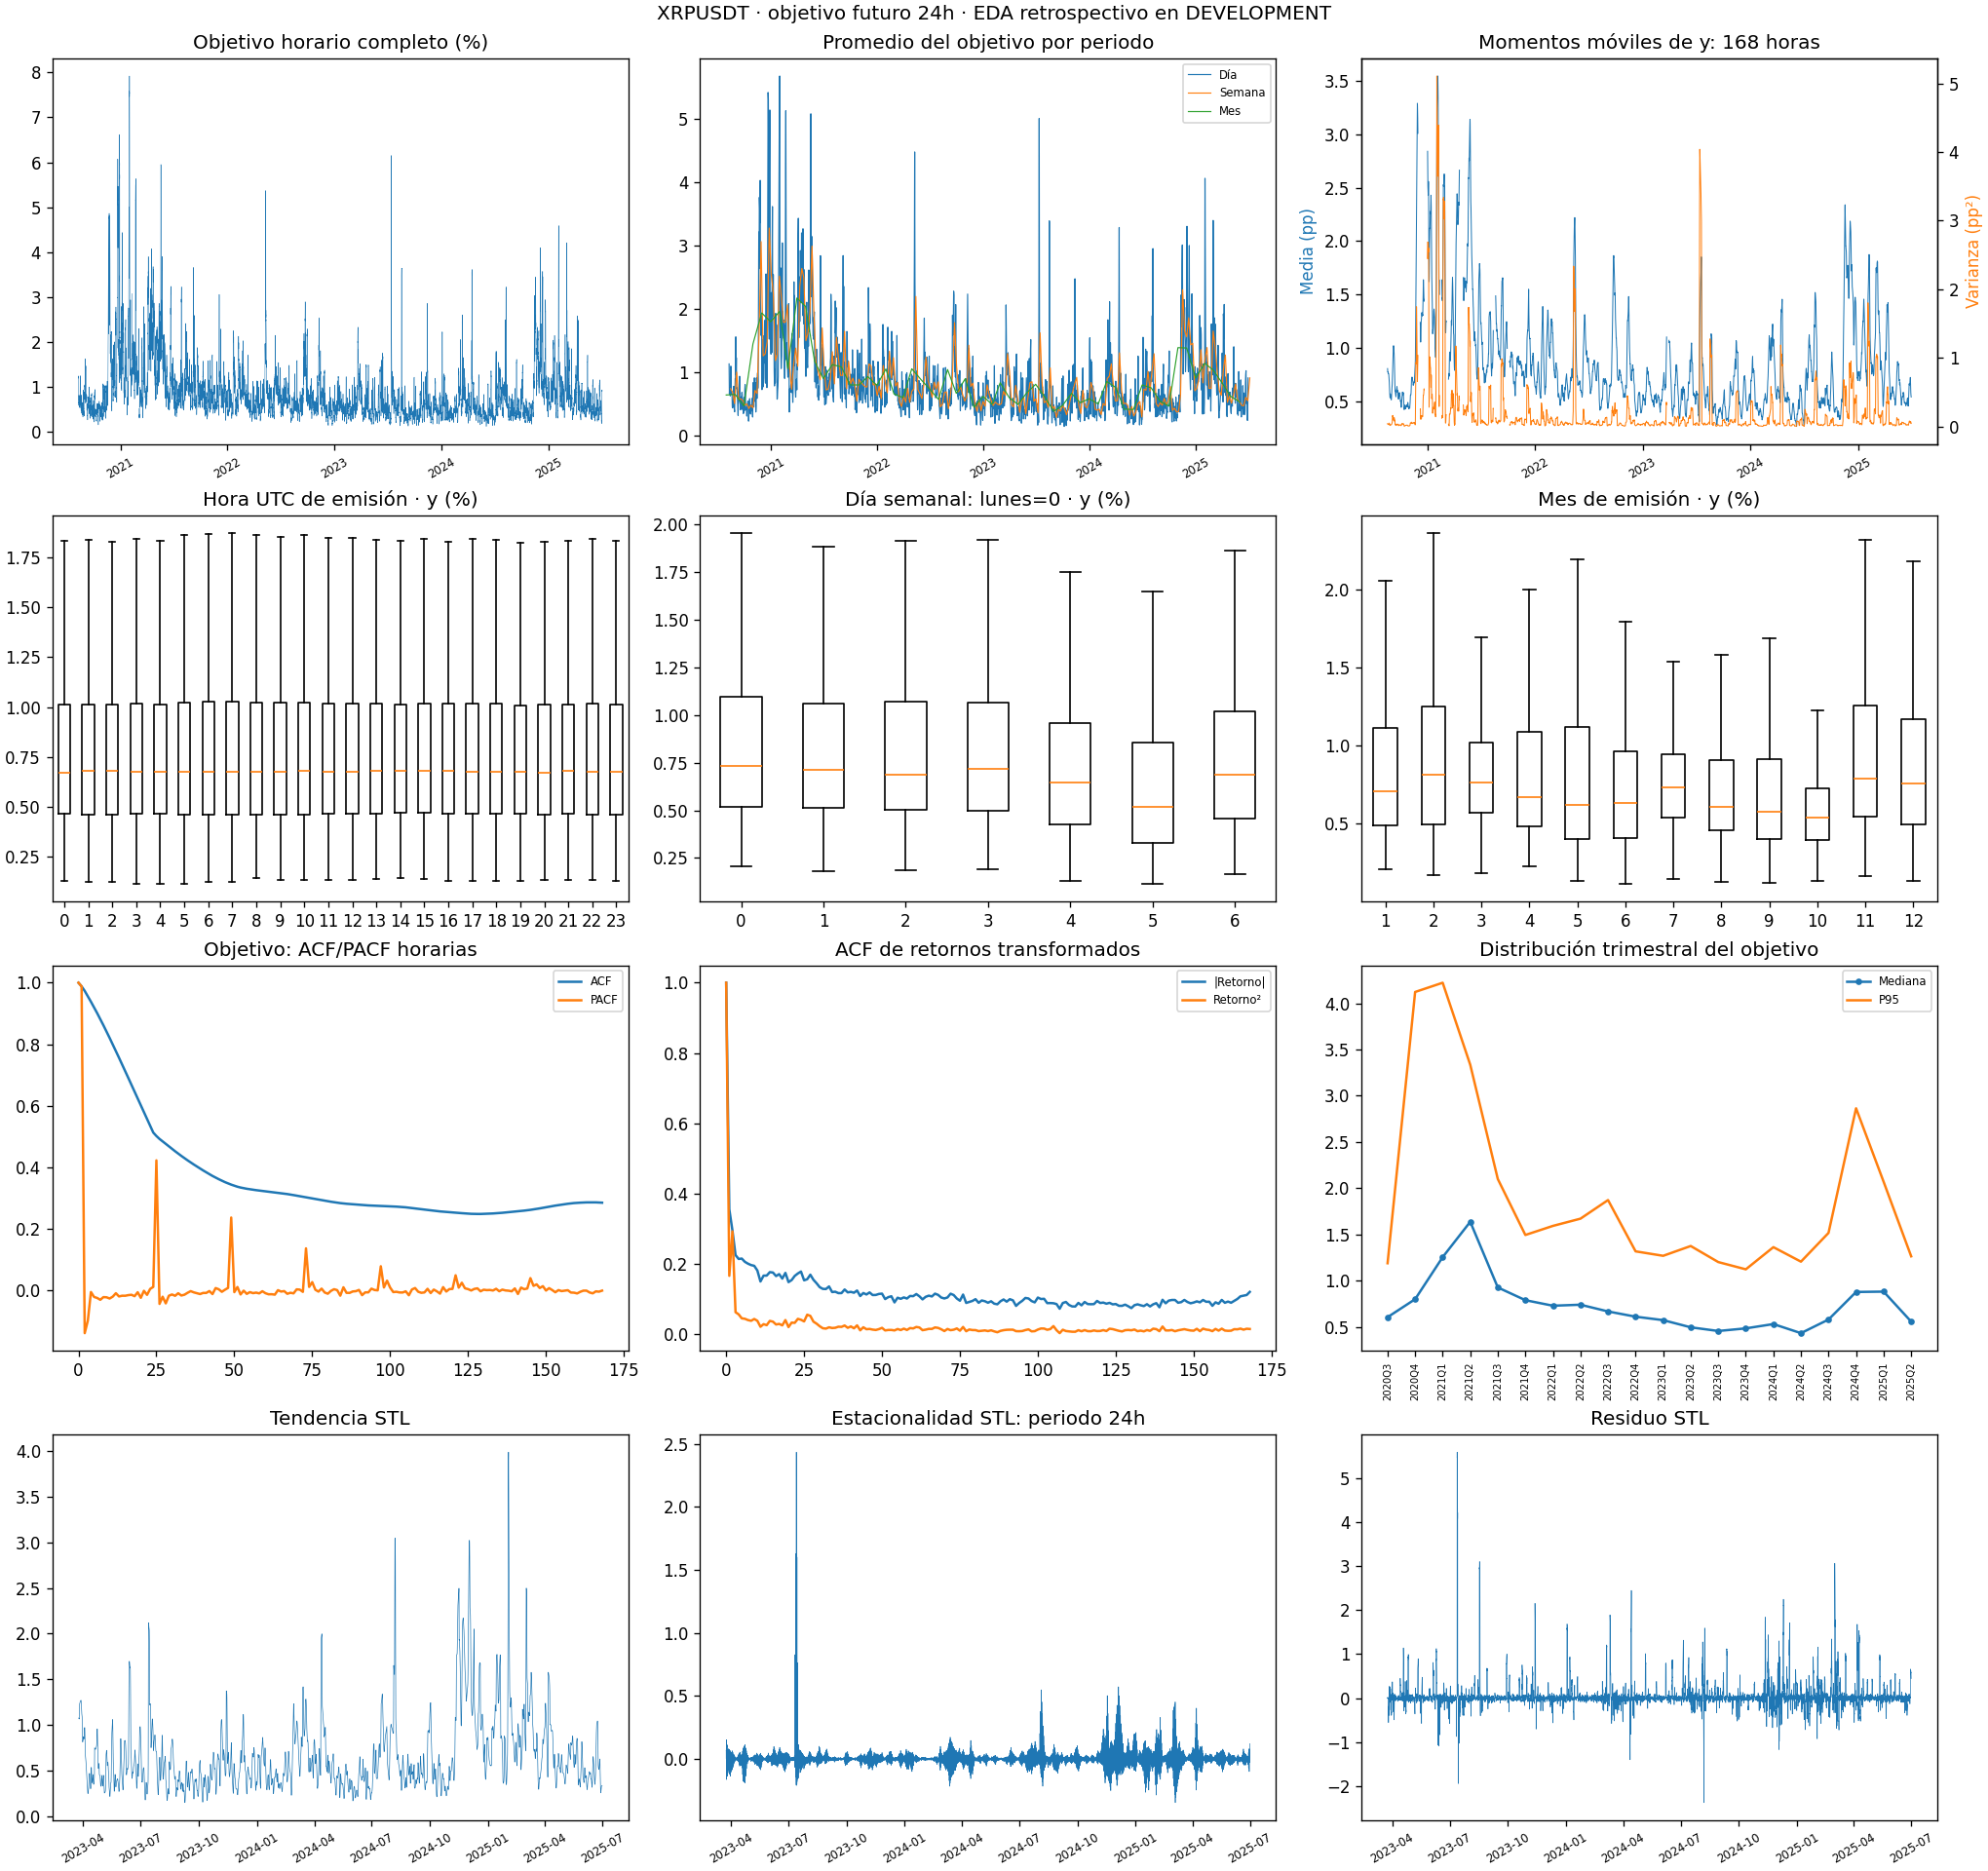

In [6]:
display(Image(filename=str(ROOT/'book/_static/figures/temporal_target_XRPUSDT.png')))